# Simple Benchmark Model

This notebook serves as a first baseline model for the Kaggle Competition.
It uses only the price data (OHLC) from the visible half of the trading session (the first 50 bars) to predict the price movement in the second half.

We will:
1. Load the training data (both seen and unseen halves).
2. Extract basic summary features from the first 50 bars for each session.
3. Calculate the target return from the final 50 bars.
4. Train a simple Random Forest Regressor on these features.
5. Generate predictions for the test set.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="darkgrid")


## 1. Load Data

In [2]:
train_seen = pd.read_parquet('data/bars_seen_train.parquet')
train_unseen = pd.read_parquet('data/bars_unseen_train.parquet')
test_seen_public = pd.read_parquet('data/bars_seen_public_test.parquet')
test_seen_private = pd.read_parquet('data/bars_seen_private_test.parquet')
test_seen = pd.concat([test_seen_public, test_seen_private], ignore_index=True)

print(f"Train Sessions: {train_seen['session'].nunique()}")
print(f"Test Sessions: {test_seen['session'].nunique()}")


Train Sessions: 1000
Test Sessions: 20000


## 2. Feature Engineering
We will extract some simple time-series features from the first 50 bars:
- Total Return: End close / Start open
- Volatility: Standard deviation of close prices
- Max/Min ratios: High/low extremes relative to the final close of the seen chunk


In [3]:
def extract_features(df):
    features = []
    # Group by session
    grouped = df.groupby('session')
    
    # Calculate features for each session
    first_open = grouped['open'].first()
    last_close = grouped['close'].last()
    
    feat_df = pd.DataFrame(index=first_open.index)
    
    # 1. Period Return
    feat_df['seen_return'] = (last_close / first_open) - 1.0
    
    # 2. Volatility
    feat_df['seen_volatility'] = grouped['close'].std()
    
    # 3. High/Low ratios
    feat_df['max_high_ratio'] = grouped['high'].max() / last_close
    feat_df['min_low_ratio'] = grouped['low'].min() / last_close
    
    return feat_df

X_train = extract_features(train_seen)
X_test = extract_features(test_seen)

X_train.head()


,seen_return,seen_volatility,max_high_ratio,min_low_ratio
session,,,,
0,0.0316,0.009548,1.002036,0.968011
1,0.0286,0.016093,1.014972,0.957612
2,0.0208,0.007259,1.003625,0.974922
3,0.0113,0.003678,1.001978,0.986750
4,0.0280,0.010271,1.002821,0.965759


## 3. Target Calculation
The objective is to maximize the Sharpe Ratio, which depends on the returns of the unseen half.
The return we actually realize by holding the position is: `close_end / close_halfway - 1`


In [4]:
# The target is the return strictly over the UNSEEN part of the session
train_halfway_close = train_seen.groupby('session')['close'].last()
train_end_close = train_unseen.groupby('session')['close'].last()

y_train = (train_end_close / train_halfway_close) - 1.0

# Quick sanity check on correlation
corr, _ = pearsonr(X_train['seen_return'], y_train)
print(f"Correlation between seen return and unseen return: {corr:.4f}")


Correlation between seen return and unseen return: -0.0712


## 4. Train Model
We will use a simple Random Forest Regressor to map the features to the expected target return.
The predicted expected return can act directly as our `target_position` (scaled up if necessary), because we want to take larger positions when we expect a larger return absolute value, and the sign indicates long/short.


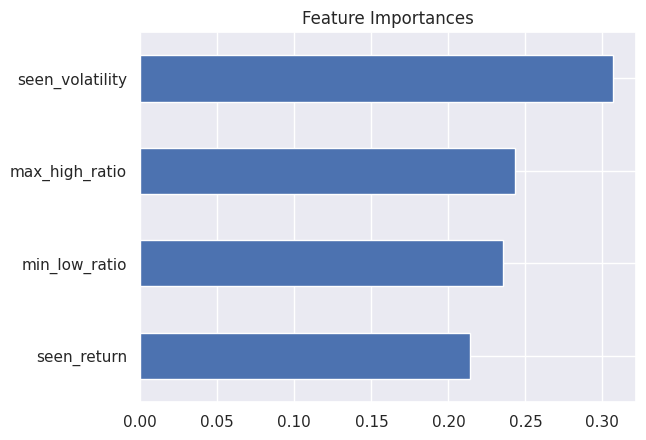

In [5]:
# Handle any NaNs just in case
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# View Feature Importances
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', title='Feature Importances')
plt.show()


## 5. Generate Predictions

In [6]:
# Predict expected returns on the train set to check in-sample performance
train_preds = model.predict(X_train)

# Calculate in-sample pseudo-Sharpe (assuming position size equals predicted return)
pnl_train = train_preds * y_train
in_sample_sharpe = np.mean(pnl_train) / np.std(pnl_train) * 16
print(f"In-sample Estimated Sharpe Ratio: {in_sample_sharpe:.4f}")

# Predict on test set
test_preds = model.predict(X_test)

# Create submission (we scale it up arbitrary by 1000 for nicer position sizes)
submission = pd.DataFrame({
    'session': X_test.index,
    'target_position': test_preds * 1000
})

submission.to_csv('submission.csv', index=False)
submission.head()


In-sample Estimated Sharpe Ratio: 5.7156


,session,target_position
0,1000,4.223620
1,1001,5.148152
2,1002,1.374582
3,1003,3.918918
4,1004,0.736425
